Homework n.2 - EDA
dataset - Titanic
https://www.kaggle.com/competitions/titanic

In [53]:
#подключение библиотек

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import plotly.express as px
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', None)

# 1. Загрузка данных
print("1. Загрузка данных")
df = pd.read_csv('/content/train.csv')

1. Загрузка данных


In [54]:
#быстрый обзор данных
df.head(10)#10 с начала

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [55]:
df.tail(10)# 10 с конца

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
882,883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,NaN,S
883,884,0,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.5000,NaN,S
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.7500,NaN,Q


In [56]:
df.shape#размер таблицы

(891, 12)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [58]:
df.describe() # стата по числовым данным

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [59]:
df.describe(include = ['object']) # cтата по текстовым данны

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


In [60]:
display(df.isnull().sum())
missing_data = df.isnull().sum()
print("\nОтсутствущая информация в доле от единицы\n")
print((missing_data) / len(df))
#видим количетсов пропусков. каюта неизвестна у абсолютного большинства


# Дубликаты
print(f"\nДубликаты строк: {df.duplicated().sum()}")

# data types check
print("\nТипы данных:")
print(df.dtypes)


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0



Отсутствущая информация в доле от единицы

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

Дубликаты строк: 0

Типы данных:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [61]:
#заполнение пропусков порта посадки модой, самой часто встречающейся

print(df['Embarked'].value_counts())
print(f"\nМода (самый частый порт): {df['Embarked'].mode()[0]}")

# Заполняем пропуски модой
df['Embarked'] = df['Embarked'].fillna(df.Embarked.mode()[0])

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Мода (самый частый порт): S


In [62]:
# удаление каюты. неизвестно 77% данных. дипсик сказал если больше 30% нет то параметр требуется удалить
if 'Cabin' in df.columns:
    df.drop('Cabin', axis=1, inplace=True)

In [63]:
# заполнение отсутствующих значений возрастов медианой т.к. медиана не чувтсвитльна к выпросам а-ля 80 лет или 0.5 года (чек краткий обзор датасета)

age_median = df['Age'].median()

df['Age'] = df['Age'].fillna(age_median)

In [64]:
# еще раз смотрим пропуски
display(df.isnull().sum())

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [65]:
# блок C для числовых колонок
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()

#удаление ID, т.к. при анализе он не потребуется
numeric_columns.remove('PassengerId')

print("Числовые признаки для анализа:")
print(numeric_columns)

Числовые признаки для анализа:
['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [66]:
# min max median mode for numeric_cols

stats_list = []
for column in numeric_columns:
    stats_list.append({
        'Признак': column,
        'Min': df[column].min(),
        'Max': df[column].max(),
        'Mean (среднее)': df[column].mean(),
        'Median (медиана)': df[column].median(),
        'Mode (мода)': df[column].mode()[0]
    })

stats_df = pd.DataFrame(stats_list)
display(stats_df)

,Признак,Min,Max,Mean (среднее),Median (медиана),Mode (мода)
0,Survived,0.00,1.0000,0.383838,0.0000,0.00
1,Pclass,1.00,3.0000,2.308642,3.0000,3.00
2,Age,0.42,80.0000,29.361582,28.0000,28.00
3,SibSp,0.00,8.0000,0.523008,0.0000,0.00
4,Parch,0.00,6.0000,0.381594,0.0000,0.00
5,Fare,0.00,512.3292,32.204208,14.4542,8.05


In [67]:
# перцентили

percentiles = [5, 10, 25, 50, 75, 90, 95]
percentile_data = {}

for col in numeric_columns:
    percentile_data[col] = [df[col].quantile(p/100) for p in percentiles]

percentile_df = pd.DataFrame(
    percentile_data,
    index=[f'{p}%' for p in percentiles]
)
display(percentile_df)

,Survived,Pclass,Age,SibSp,Parch,Fare
5%,0.0,1.0,6.0,0.0,0.0,7.22500
10%,0.0,1.0,16.0,0.0,0.0,7.55000
25%,0.0,2.0,22.0,0.0,0.0,7.91040
50%,0.0,3.0,28.0,0.0,0.0,14.45420
75%,1.0,3.0,35.0,1.0,0.0,31.00000
90%,1.0,3.0,47.0,1.0,2.0,77.95830
95%,1.0,3.0,54.0,3.0,2.0,112.07915


In [68]:
# дисперсия (variance) асимметрия(skewness) и эксцесс(kurtosis)
advanced_stats = []
for col in numeric_columns:
    advanced_stats.append({
        'Признак': col,
        'Дисперсия (variance)': df[col].var(),
        'Асимметрия (skewness)': df[col].skew(),
        'Эксцесс (kurtosis)': df[col].kurtosis()
    })

advanced_df = pd.DataFrame(advanced_stats)
display(advanced_df)

,Признак,Дисперсия (variance),Асимметрия (skewness),Эксцесс (kurtosis)
0,Survived,0.236772,0.478523,-1.775005
1,Pclass,0.699015,-0.630548,-1.280015
2,Age,169.512498,0.510245,0.993871
3,SibSp,1.216043,3.695352,17.880420
4,Parch,0.649728,2.749117,9.778125
5,Fare,2469.436846,4.787317,33.398141


как можно видеть поле fare обладает высокой дисперсией, асиметрией и эксцессом. это говорит о большой разбежке в плате за билеты (высокая дисперсия). так же много билетов было приобретено за малую цену (положительная асимметрия). в третьих высокий эксцесс говорит о наличии выбросов в полях платы fare и поле с родствнниками SipSp. высокая дисперсия в поле с возрастом говорит о значительных отклонениях значений возраста от среднего значения(среднее отклонение по возрасту составляет 13 лет(корень из среденго арифметического квадрато отклонения))

In [69]:
# one hot encoder
# здесь male/female будет разделен на 0/1

print("Уникальные значения в колонке пола (sex):")
print(df['Sex'].value_counts())

sex_dummies = pd.get_dummies(df['Sex'])

print("\nРезультат One-Hot Encoding:")
display(sex_dummies.head())

#добавление двух новых и удаление старой
if 'male' not in df.columns:
  df = pd.concat([df, sex_dummies], axis=1)
#df.drop('Sex', axis=1, inplace=True)

print("после добавления новых колонок:")
display(df.head())

Уникальные значения в колонке пола (sex):
Sex
male      577
female    314
Name: count, dtype: int64

Результат One-Hot Encoding:


,female,male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True


после добавления новых колонок:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,female,male
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,True,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,True,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,True,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,False,True


In [70]:
# target encoding для портов. в новой колонке типо рейтинг выживаемости
# я пообщадся с дипсиком и понял что моя задумка с ассиметрией вместо среднего подходит хуже изза более сложной интерпретации
embarked_survival = df.groupby('Embarked')['Survived'].mean()
df['Embarked_encoded'] = df['Embarked'].map(embarked_survival)

display(embarked_survival)

print("изменения в dataframe:")
display(df[['Embarked', 'Embarked_encoded']].head(10))

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.339009


изменения в dataframe:


,Embarked,Embarked_encoded
0,S,0.339009
1,C,0.553571
2,S,0.339009
3,S,0.339009
4,S,0.339009
5,Q,0.389610
6,S,0.339009
7,S,0.339009
8,S,0.339009
9,C,0.553571


чуток про feature hashing. в данном случае из колонок с подходящими значениями только id,имя, билет или номер каюты который мы удалили.

смысла в id нет в целом. от того каким именем джон или майк обладает парень или замужем\не замужем девушка выживаемость маловероятно что зависит

билеты тоже хэшировать не обязательно, их только 681 уникальный. в данном случае мне кажется хэширование применять не требуется т.к. объем данных малый а точность изза коллизий снизится значительно.

In [71]:
#всего билетов
total_tickets = len(df['Ticket'])
#уникальных билетов
unique_tickets = df['Ticket'].nunique()
#дубликаты
duplicates_count = total_tickets - unique_tickets
print(f"Всего билетов: {total_tickets}")
print(f"Уникальных билетов: {unique_tickets}")
print(f"Дубликатов: {duplicates_count}")

Всего билетов: 891
Уникальных билетов: 681
Дубликатов: 210


In [72]:
# добавление новых фичерс: 1) одинокий пассажир 2) ребенок ли 3) размер семьи - вспомогательный для 1

df['FamilySize'] = df['SibSp'] + df['Parch']
df['IsAlone'] = (df['FamilySize'] == 0).astype(int)

df['IsChild'] = (df['Age'] < 18).astype(int)

# что получили
print(df[['IsAlone', 'IsChild', 'FamilySize']].head(20))
print(f"\nОдиноких: {df['IsAlone'].sum()}")
print(f"Детей: {df['IsChild'].sum()}")

    IsAlone  IsChild  FamilySize
0         0        0           1
1         0        0           1
2         1        0           0
3         0        0           1
4         1        0           0
5         1        0           0
6         1        0           0
7         0        1           4
8         0        0           2
9         0        1           1
10        0        1           2
11        1        0           0
12        1        0           0
13        0        0           6
14        1        1           0
15        1        0           0
16        0        1           5
17        1        0           0
18        0        0           1
19        1        0           0

Одиноких: 537
Детей: 113


блок E - визуализация


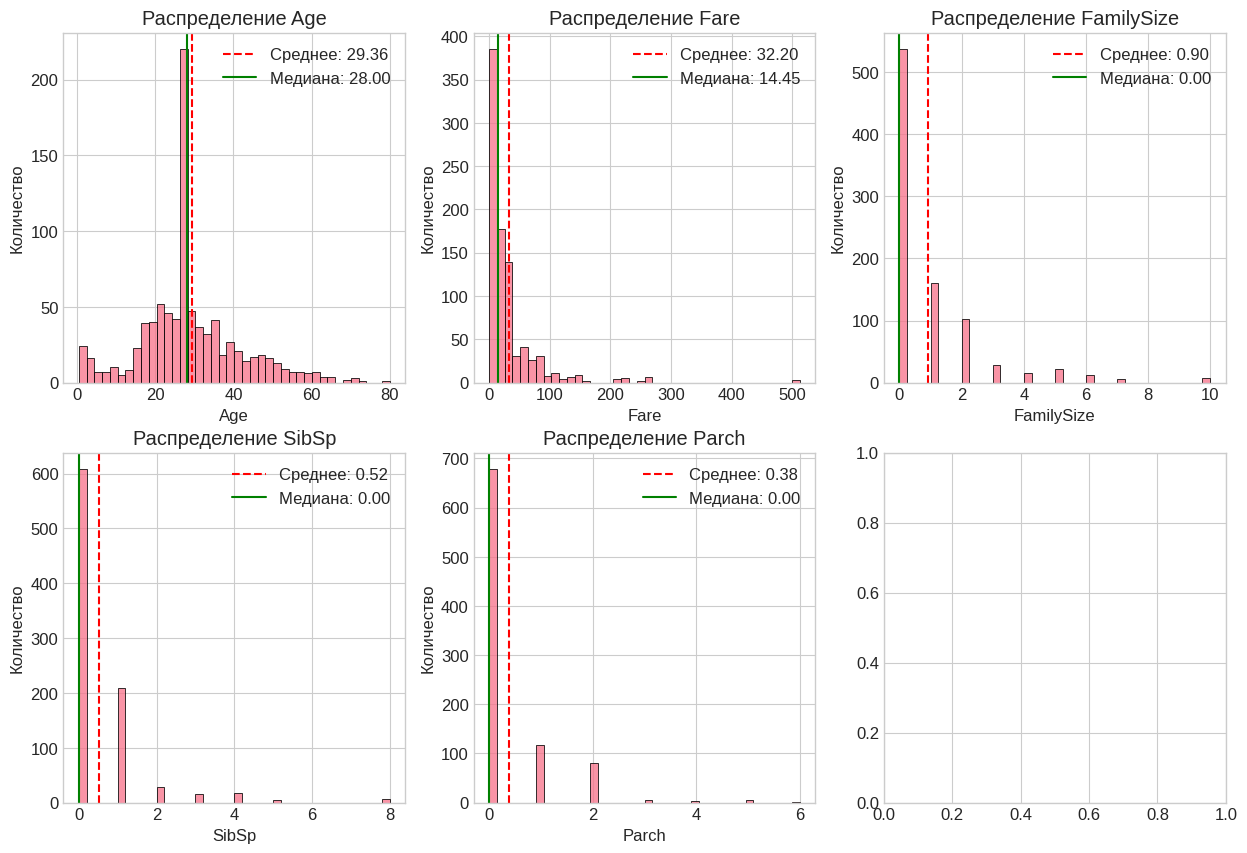

In [73]:
# Числовые признаки для анализа
num_features = ['Age', 'Fare', 'FamilySize', 'SibSp', 'Parch']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, feature in enumerate(num_features):
    sns.histplot(df[feature], bins=40, ax=axes[i])
    axes[i].set_ylabel('Количество')
    axes[i].set_title(f'Распределение {feature}')
    axes[i].axvline(df[feature].mean(), color='red', linestyle='--', label=f'Среднее: {df[feature].mean():.2f}')
    axes[i].axvline(df[feature].median(), color='green', linestyle='-', label=f'Медиана: {df[feature].median():.2f}')
    axes[i].legend()




на графике с распределением по фозрасту жестко виден скачок в районе медианы. если вспомнить то выше все пропуски в колонке возраст были заполнен медианным значением :-)

Ниже - scattler plot

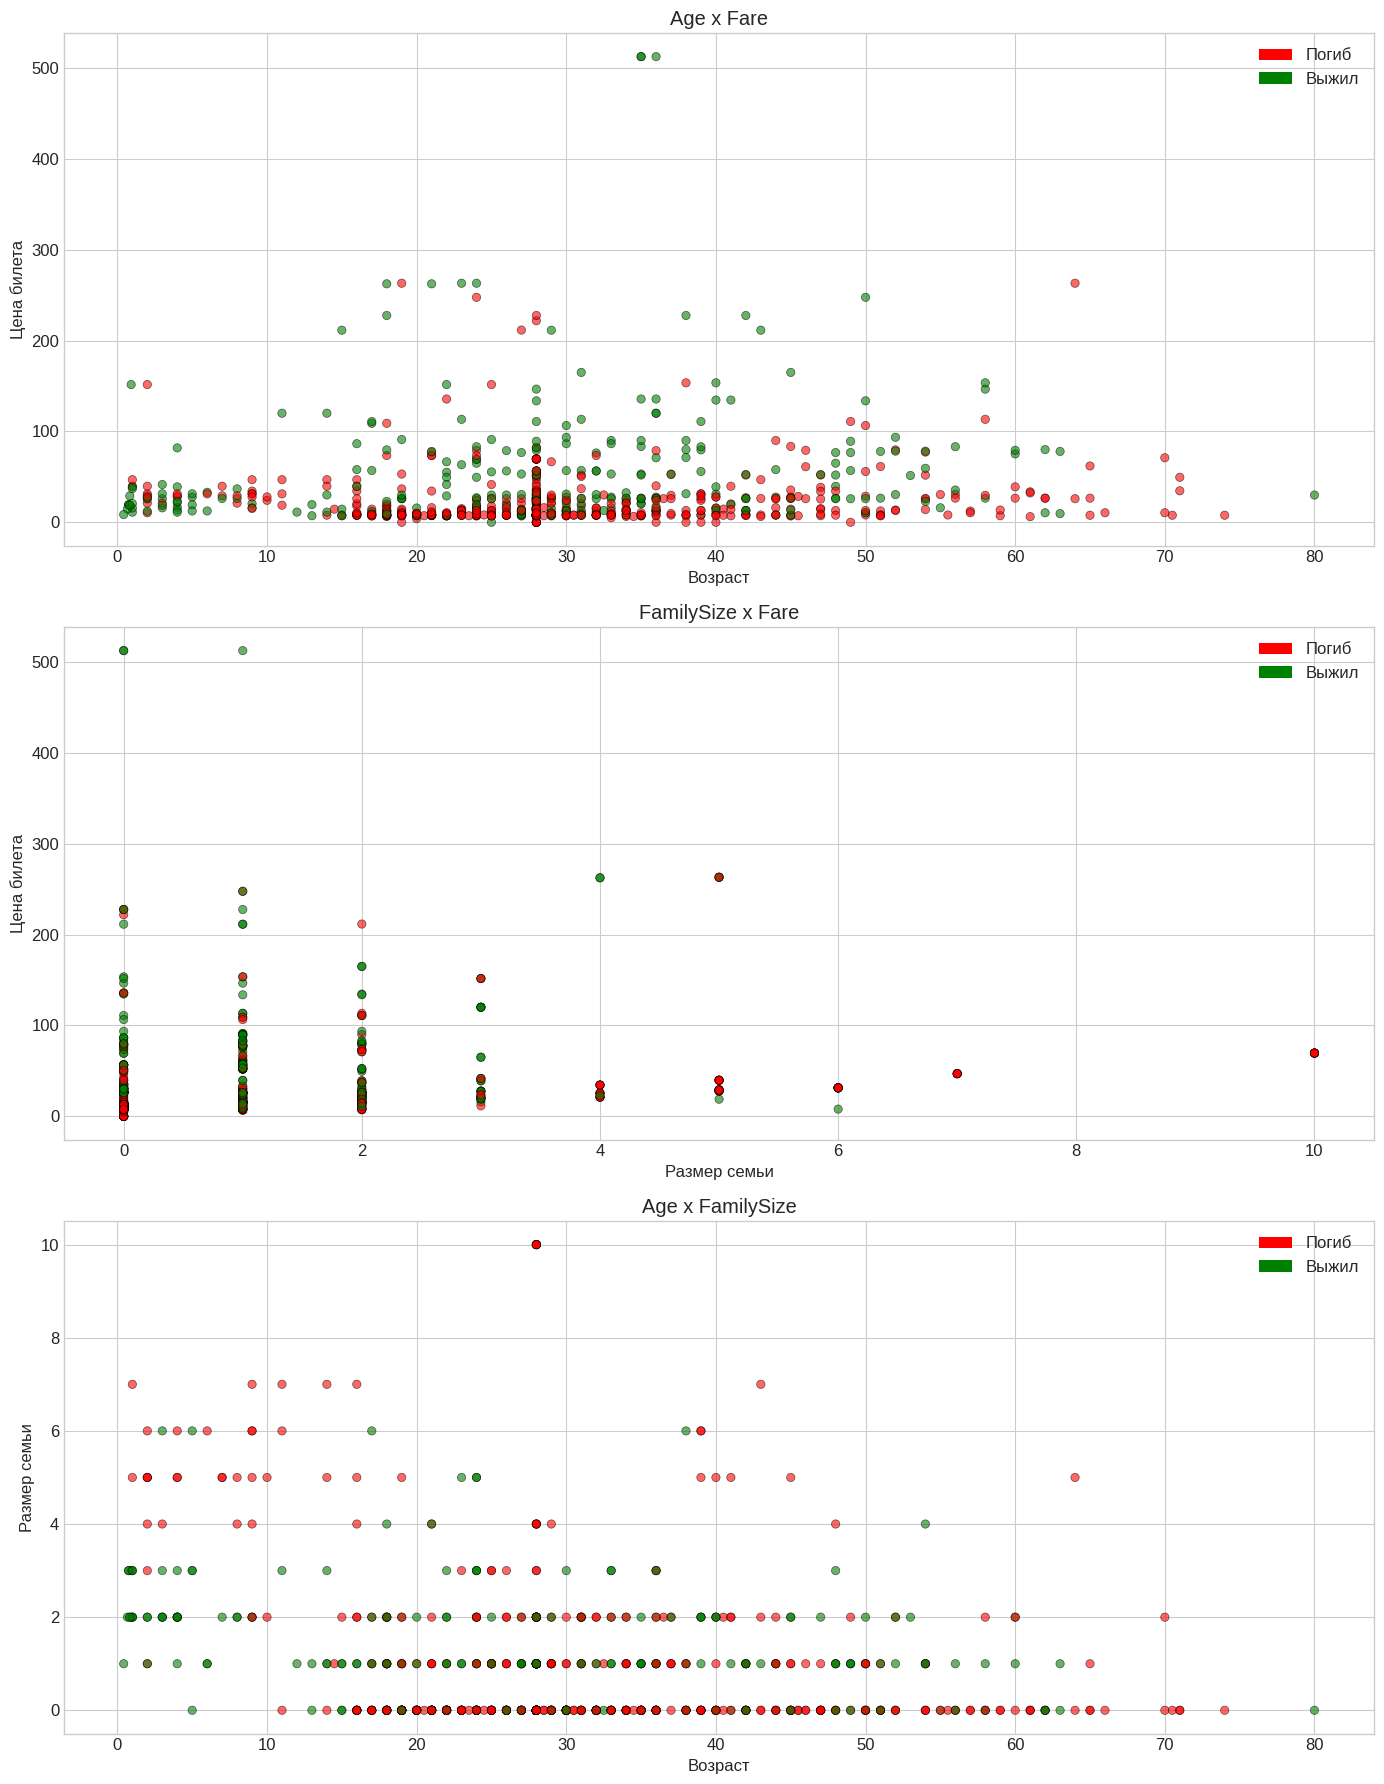

In [74]:
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# Age и Fare
colors = ['red' if s == 0 else 'green' for s in df['Survived']]
axes[0].scatter(df['Age'], df['Fare'], c=colors, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('Возраст')
axes[0].set_ylabel('Цена билета')
axes[0].set_title('Age x Fare')
# Добавим легенду вручную
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='Погиб'),
                   Patch(facecolor='green', label='Выжил')]
axes[0].legend(handles=legend_elements)

# FamilySize и Fare
axes[1].scatter(df['FamilySize'], df['Fare'], c=colors, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('Размер семьи')
axes[1].set_ylabel('Цена билета')
axes[1].set_title('FamilySize x Fare')
axes[1].legend(handles=legend_elements)

# age и family size
axes[2].scatter(df['Age'], df['FamilySize'], c=colors, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[2].set_xlabel('Возраст')
axes[2].set_ylabel('Размер семьи')
axes[2].set_title('Age x FamilySize')
axes[2].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

из графиков видно что чем младше человек тем выше выживаемость (хорошо видно на графике 1 и 3)

на 1 графике чем ниже цена билета тем больше красного(меньше выэживаемость)

на графике 3 после 60 лет величина семьи уменьшается(не уверен)

/tmp/ipykernel_219/4041742664.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Age', data=df, ax=axes[0], palette=['red', 'green'])
/tmp/ipykernel_219/4041742664.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Погиб', 'Выжил'])
/tmp/ipykernel_219/4041742664.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Fare', data=df, ax=axes[1], palette=['red', 'green'])
/tmp/ipykernel_219/4041742664.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xti

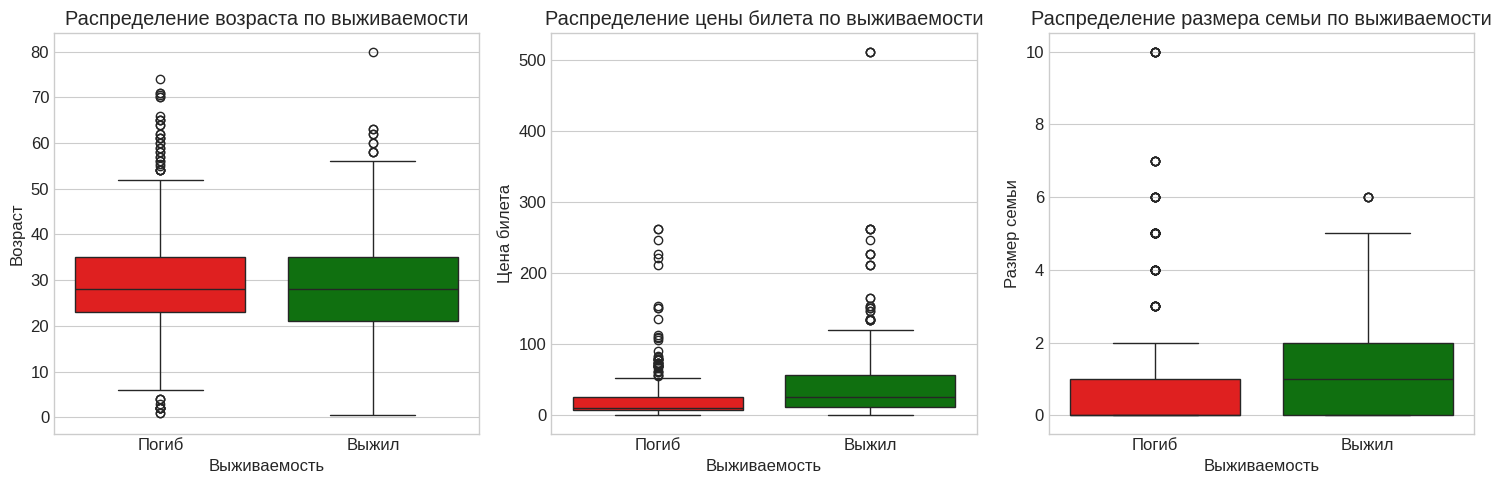

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Age по выживаемости
sns.boxplot(x='Survived', y='Age', data=df, ax=axes[0], palette=['red', 'green'])
axes[0].set_title('Распределение возраста по выживаемости')
axes[0].set_xlabel('Выживаемость')
axes[0].set_ylabel('Возраст')
axes[0].set_xticklabels(['Погиб', 'Выжил'])

# Fare по выживаемости
sns.boxplot(x='Survived', y='Fare', data=df, ax=axes[1], palette=['red', 'green'])
axes[1].set_title('Распределение цены билета по выживаемости')
axes[1].set_xlabel('Выживаемость')
axes[1].set_ylabel('Цена билета')
axes[1].set_xticklabels(['Погиб', 'Выжил'])

# FamilySize по выживаемости
sns.boxplot(x='Survived', y='FamilySize', data=df, ax=axes[2], palette=['red', 'green'])
axes[2].set_title('Распределение размера семьи по выживаемости')
axes[2].set_xlabel('Выживаемость')
axes[2].set_ylabel('Размер семьи')
axes[2].set_xticklabels(['Погиб', 'Выжил'])

plt.tight_layout()
plt.show()

выбросы в категории цены за билет, величины семьи

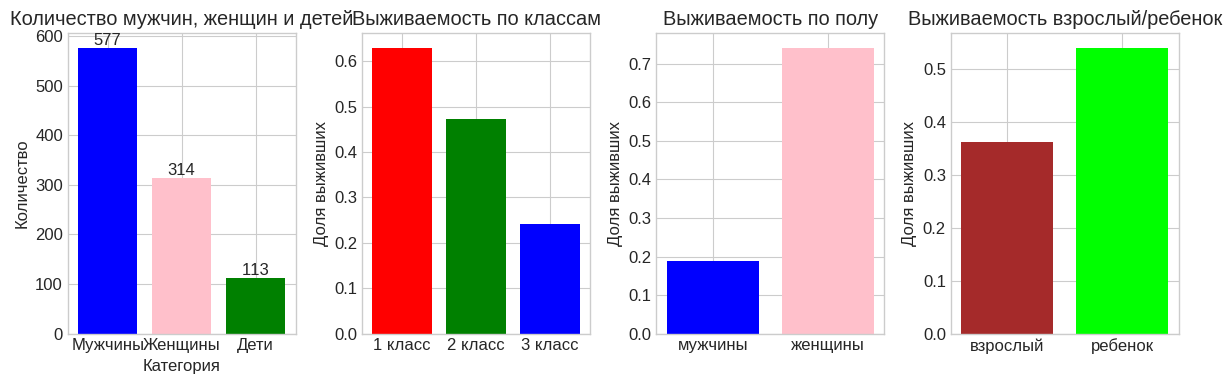

In [76]:
fig, axes = plt.subplots(1, 4, figsize=(12, 4))

# мужчины женщин дети
male_count = df[df['male']==1].shape[0]
female_count = df[df['female']==1].shape[0]
child_count = df[df['IsChild']==1].shape[0]

categories = ['Мужчины', 'Женщины', 'Дети']
counts = [male_count, female_count, child_count]
colors = ['blue', 'pink', 'green']

axes[0].bar(categories, counts, color=colors)
axes[0].set_title('Количество мужчин, женщин и детей')
axes[0].set_ylabel('Количество')
axes[0].set_xlabel('Категория')

for i, v in enumerate(counts):
    axes[0].text(i, v + 5, str(v), ha='center')

# Выживаемость по классам
pclass_survival = df.groupby('Pclass')['Survived'].mean()
axes[1].bar(['1 класс', '2 класс', '3 класс'], pclass_survival.values,
            color=['red', 'green', 'blue'])
axes[1].set_title('Выживаемость по классам')
axes[1].set_ylabel('Доля выживших')

# выживаемость по полу
sex_survival = df.groupby('female')['Survived'].mean()
axes[2].bar(['мужчины', 'женщины'], sex_survival.values,
            color=['blue', 'pink'])
axes[2].set_title('Выживаемость по полу')
axes[2].set_ylabel('Доля выживших')

# выживаемость ребенок\взрослый
child_survival = df.groupby('IsChild')['Survived'].mean()
axes[3].bar(['взрослый', 'ребенок'], child_survival.values,
            color=['brown', 'lime'])
axes[3].set_title('Выживаемость взрослый/ребенок')
axes[3].set_ylabel('Доля выживших')

plt.tight_layout()
plt.show()

видно что выживаемость в 1 классе выше чем в 3ем
выживаеомсть среди женщин +-75%. среди мужчин +-19% (кстати соответсвует данным в гугле)

выживаеомтсь среди детей выше(спасали в первую очередь)

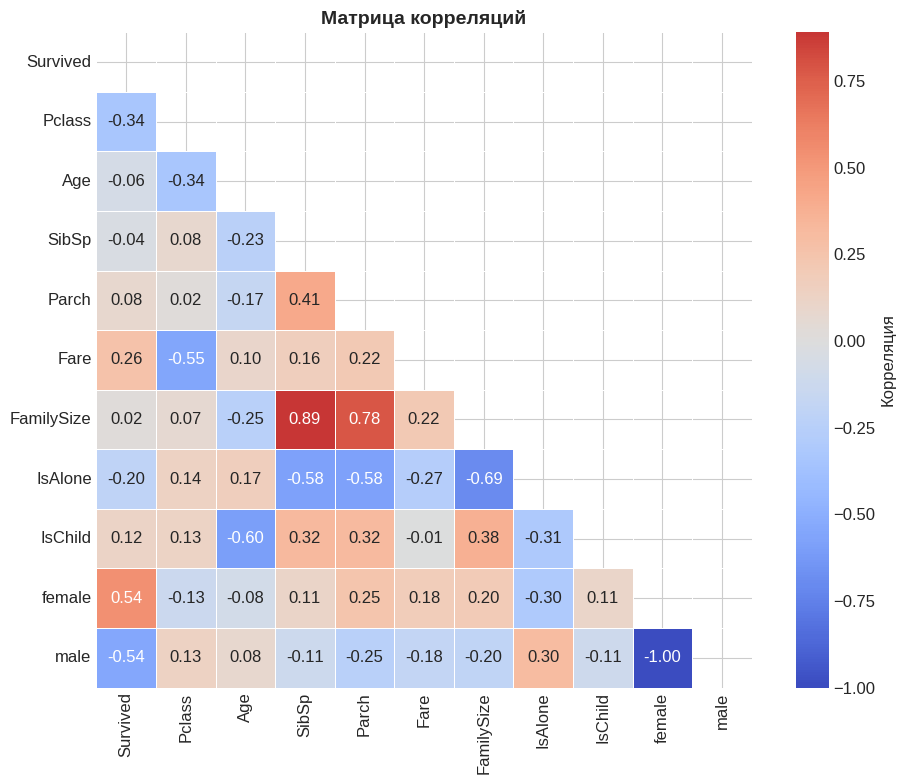

In [77]:
# Выбираем числовые колонки
corr_features = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
                 'FamilySize', 'IsAlone', 'IsChild', 'female', 'male']

# Считаем корреляцию
corr_matrix = df[corr_features].corr()

# Создаем маску для верхнего треугольника
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Рисуем heatmap с маской
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
cmap='coolwarm', center=0, square=True, linewidths=0.5,
cbar_kws={'label': 'Корреляция'})

plt.title('Матрица корреляций', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

что можно увиддеть на графике корреляций:

male female -1 не удивительно

female - survived +0.54 (если женщина выживаемость выше)

fare - survived +0.26 (выше цена выше выживаемость)

ischild - age -0.60 (не удивтельно если ребенок то возраст меньше)

fare - pclass -0.55 чем выше цена тем ниже цифра класса

зависимость familysize isAlone Parch SibSp очевидна(первые два это кастомные фичи основанные на Parch and SibSp)

блок F

буллеты

1. survival rate - 0.38
2. пропуски в каютах следовало удалить

3.значиетльное преобладание мужчин над женщинами в датасете

4.большинство билетов были дешевыми. медиана 14.5 доллара

5.медианный возраст пассажиров был 29 лет

6.высокая дисперсия и эксцесс у fare свидельствуют о большом разбросе значений
 с наличием выбрсосов

7.высокая коррелиация между полом и survival rate


ГИПОТЕЗЫ

1.Выживаемость среди женщины выше чем среди мужчин

2. выживаемось среди детей выше чем среди взрослых

3. выживаемость среди пассажиров 1 класса выше чем у второго и третьего

4. выше стоимость билета -> выше выживаемость

таким образом работало правило "первыми спасают женщин и детей" работало. кроме того обладатели более дорогих билетов в 1 классе выживали чаще


Далее наверное следовало бы оформить масштабирование. Наверное еще колонку с возрастом заполнио бы медианой, но с небольшим рандомным разбросом +- 10% от значения. ибо пик людей с возрастом в районе медианного очень большой

дипсик помог с синтаксисом



